Comparison Settings:
Cryptocurrency: Bitcoin (BTC)
Window Size: 13 weeks
Weekly Investment: $100

Strategy A (Conservative) Thresholds:
  - Invest 50% if |z-score| >= 2.0
  - Invest 30% if |z-score| >= 1.5
  - Invest 20% if |z-score| >= 1.0
  - Invest 10% if |z-score| >= 0.5
  - Invest 5% if |z-score| >= 0.0

Strategy B (Aggressive) Thresholds:
  - Invest 90% if |z-score| >= 2.0
  - Invest 70% if |z-score| >= 1.5
  - Invest 50% if |z-score| >= 1.0
  - Invest 30% if |z-score| >= 0.5
  - Invest 20% if |z-score| >= 0.0
Using recent data file: data/BTC_weekly_20250502.csv

Data Preview:
                        date         price
0 2020-05-03 23:21:11.284083   7483.570765
1 2020-05-10 23:21:11.284083   5209.563450
2 2020-05-17 23:21:11.284083  10036.362884
3 2020-05-24 23:21:11.284083  15302.425659
4 2020-05-31 23:21:11.284083   7394.397951
Total records: 260

Performance Comparison:
Initial Investment (both strategies): $26000.00

Strategy A (Conservative):
  - Final Portfolio Value: $3928

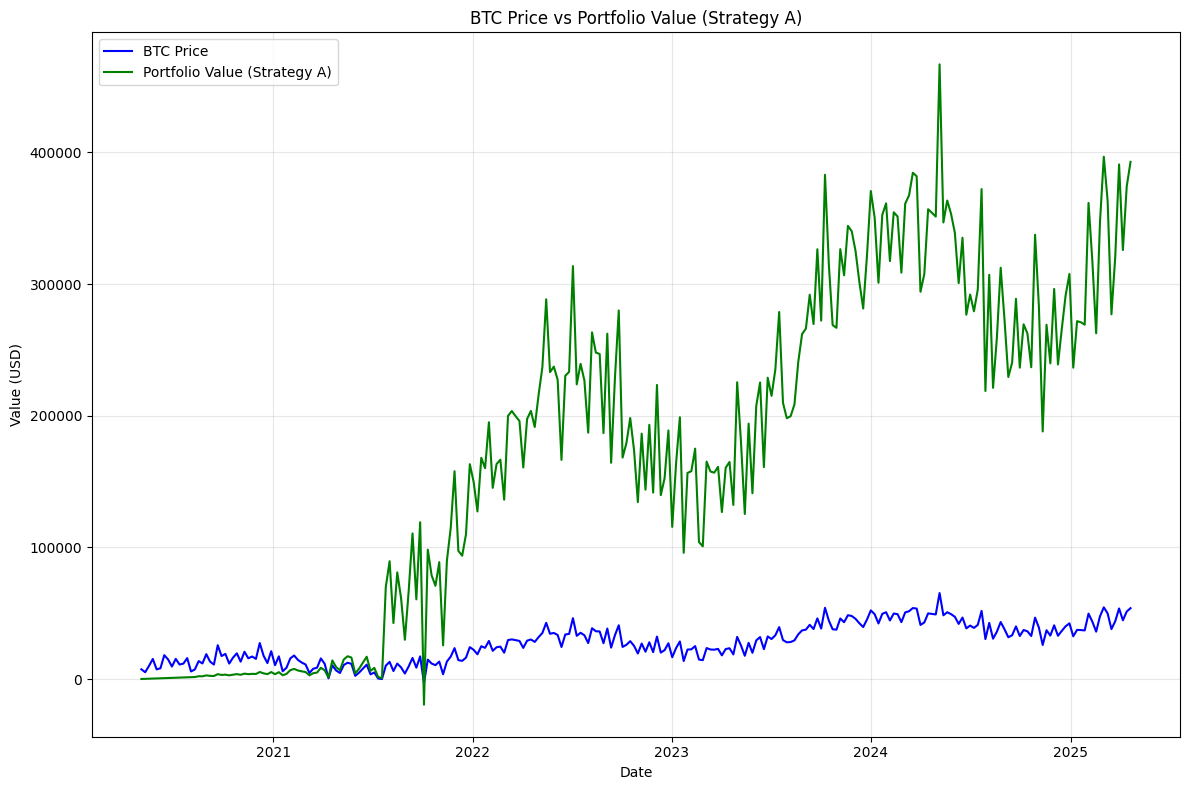

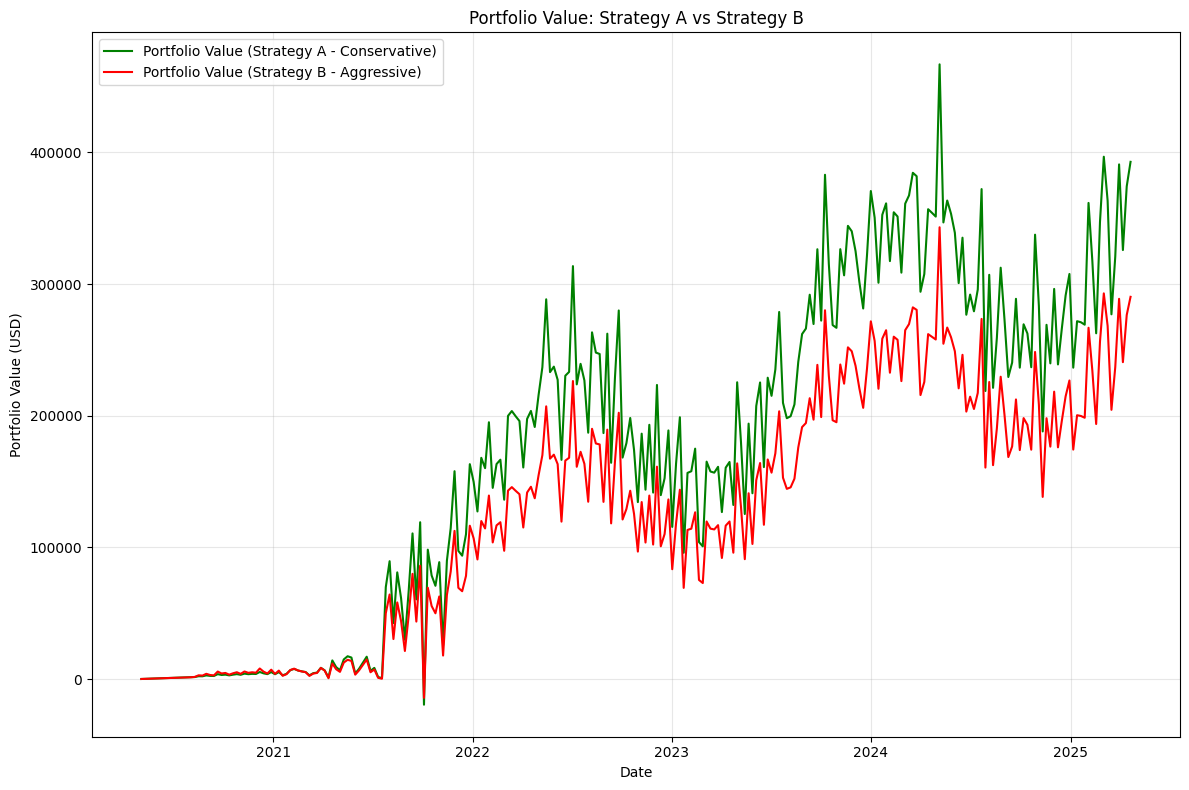

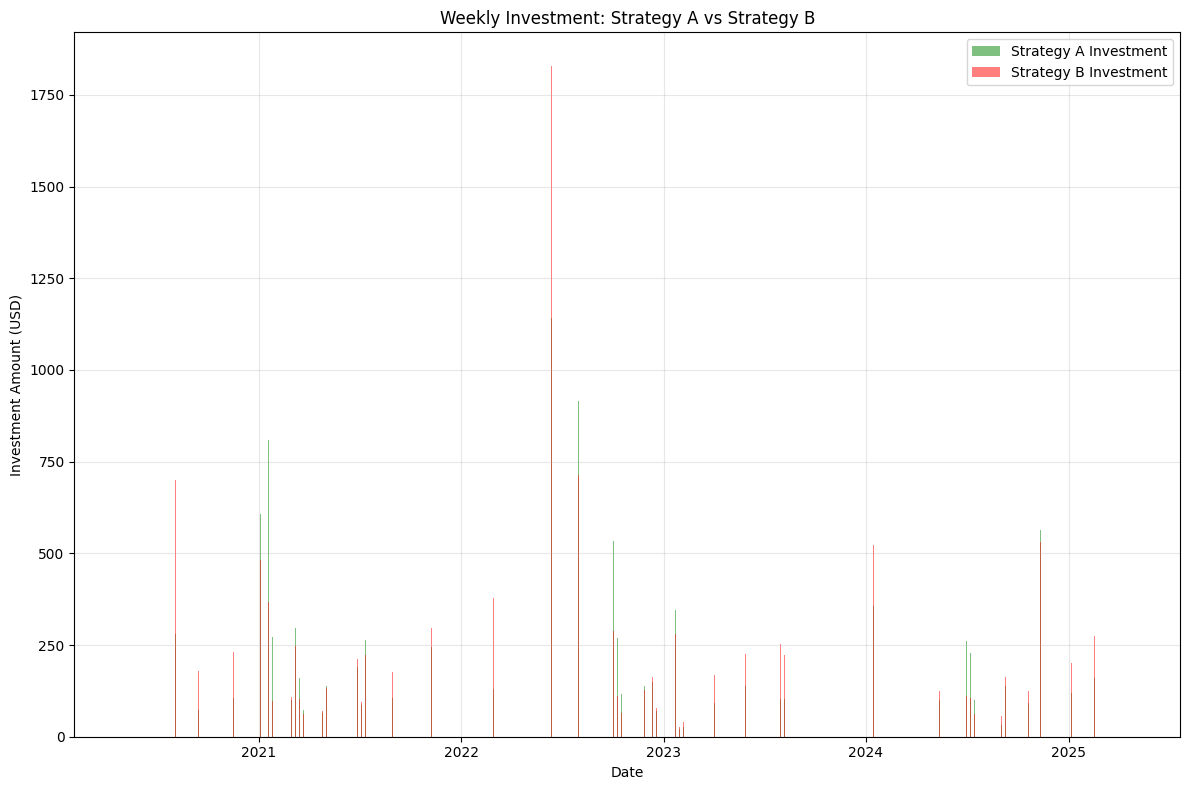

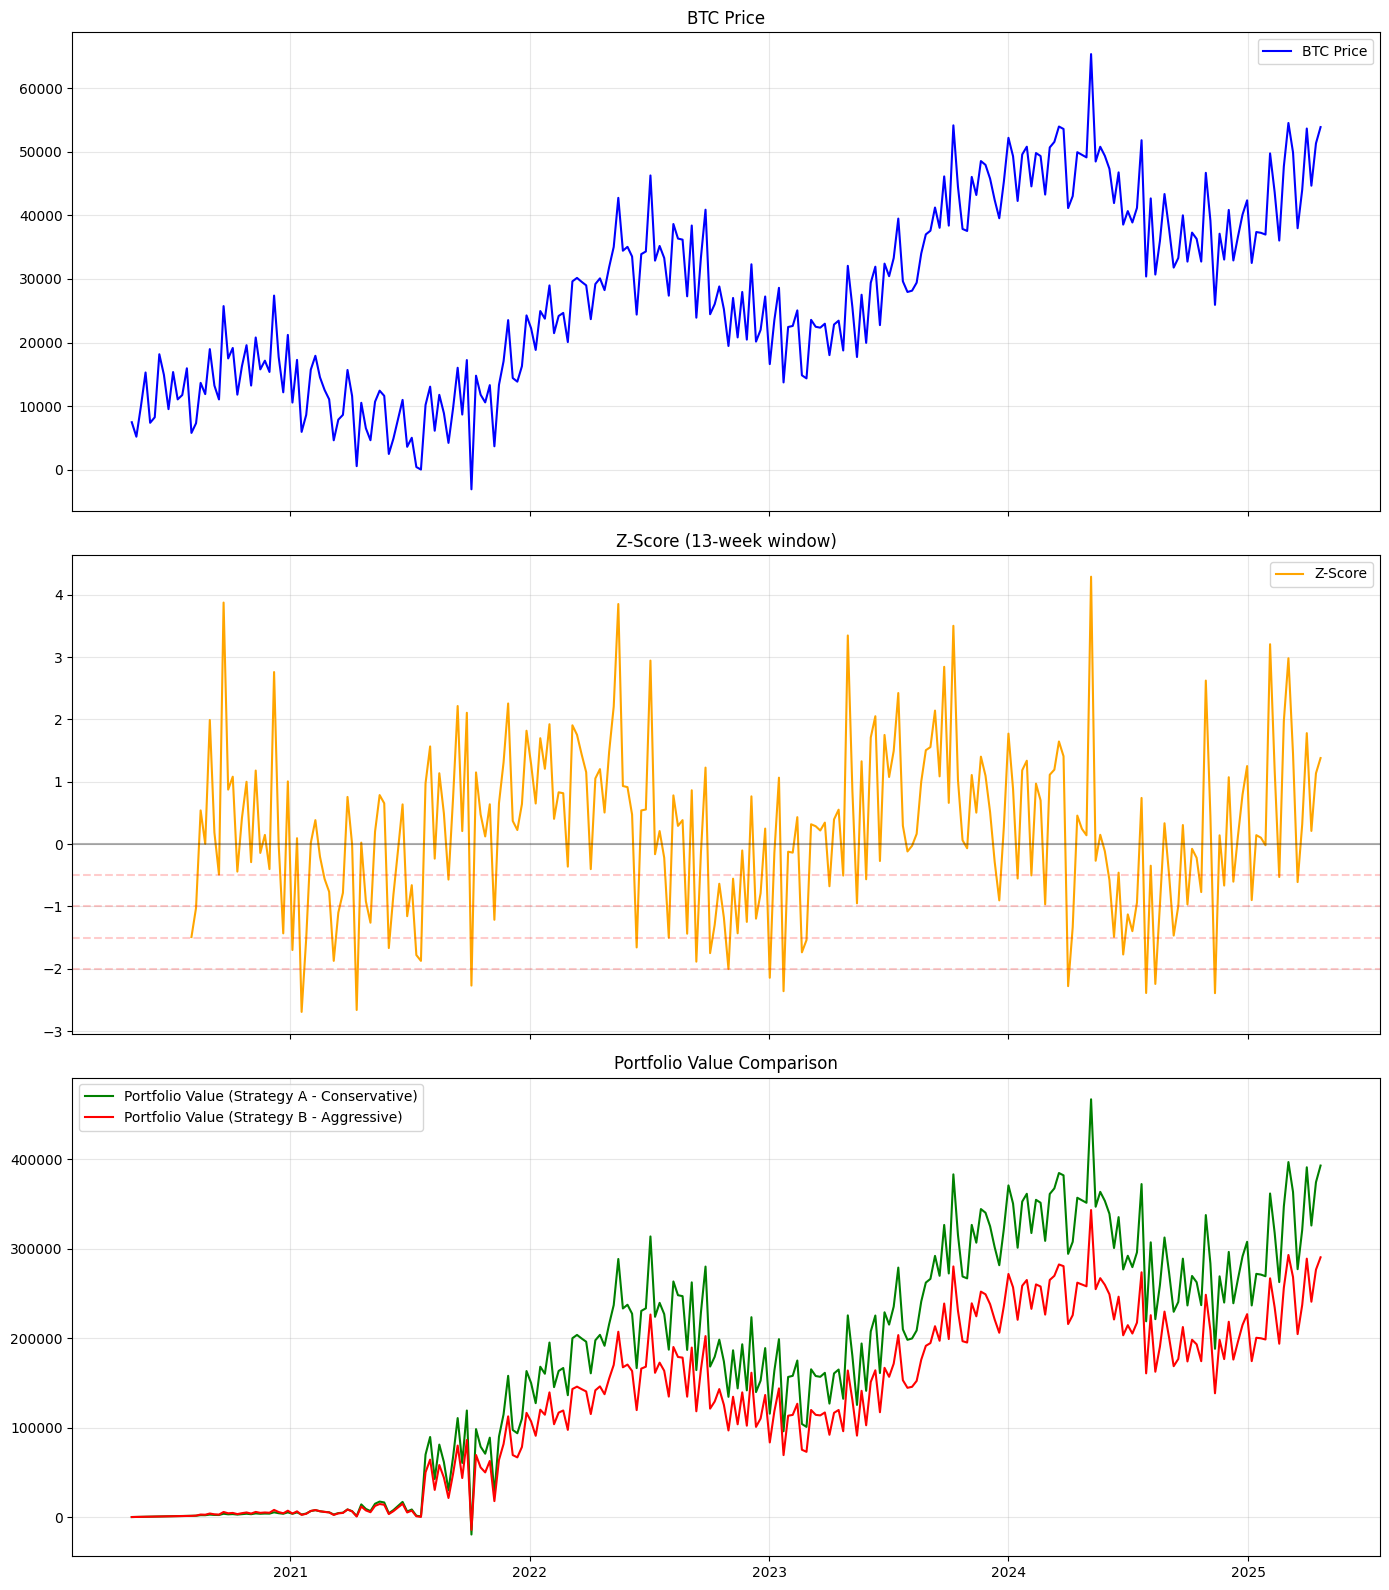


Results saved to 'results/' directory


In [1]:
# Z-Score Based Cryptocurrency Investment Strategy Comparison

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
import copy

# Import our modules
import constants
from strategy import ZScoreInvestmentStrategy
from data_utils import get_weekly_data, generate_sample_data

# Define two different sets of Z-score thresholds for comparison
# Strategy A: Conservative approach (invests smaller percentages)
Z_SCORE_THRESHOLDS_A = [
    (0.5, 2.0),  # Invest 50% if |z| >= 2.0 (strongly undervalued)
    (0.3, 1.5),  # Invest 30% if |z| >= 1.5
    (0.2, 1.0),  # Invest 20% if |z| >= 1.0
    (0.1, 0.5),  # Invest 10% if |z| >= 0.5
    (0.05, 0.0)  # Invest 5% if |z| >= 0.0 (slightly undervalued)
]

# Strategy B: Aggressive approach (invests larger percentages)
Z_SCORE_THRESHOLDS_B = [
    (0.9, 2.0),  # Invest 90% if |z| >= 2.0 (strongly undervalued)
    (0.7, 1.5),  # Invest 70% if |z| >= 1.5
    (0.5, 1.0),  # Invest 50% if |z| >= 1.0
    (0.3, 0.5),  # Invest 30% if |z| >= 0.5
    (0.2, 0.0)   # Invest 20% if |z| >= 0.0 (slightly undervalued)
]

# Display strategy parameters
print(f"Comparison Settings:")
print(f"====================")
print(f"Cryptocurrency: {constants.CRYPTO_NAME} ({constants.CRYPTO_SYMBOL})")
print(f"Window Size: {constants.WINDOW_SIZE} weeks")
print(f"Weekly Investment: ${constants.WEEKLY_INVESTMENT}")

print("\nStrategy A (Conservative) Thresholds:")
for threshold in Z_SCORE_THRESHOLDS_A:
    print(f"  - Invest {threshold[0]*100:.0f}% if |z-score| >= {threshold[1]}")

print("\nStrategy B (Aggressive) Thresholds:")
for threshold in Z_SCORE_THRESHOLDS_B:
    print(f"  - Invest {threshold[0]*100:.0f}% if |z-score| >= {threshold[1]}")

# Get cryptocurrency data (fetch from API or use sample data)
if constants.CMC_API_KEY:
    # If API key is available, try to get real data
    data_file = get_weekly_data()
    if data_file:
        # Load data from the saved CSV
        crypto_data = pd.read_csv(data_file)
        crypto_data['date'] = pd.to_datetime(crypto_data['date'])
    else:
        print("Failed to get data from API. Using sample data instead.")
        crypto_data = generate_sample_data()
else:
    # No API key, use sample data
    print("No CoinMarketCap API key provided. Using sample data for demonstration...")
    crypto_data = generate_sample_data()

# Preview the data
print("\nData Preview:")
print("=============")
print(crypto_data.head())
print(f"Total records: {len(crypto_data)}")

# Run Strategy A (Conservative)
# Create a temporary copy of the constants module's threshold setting
original_thresholds = constants.Z_SCORE_THRESHOLDS
constants.Z_SCORE_THRESHOLDS = Z_SCORE_THRESHOLDS_A

strategy_a = ZScoreInvestmentStrategy(
    window_size=constants.WINDOW_SIZE, 
    weekly_investment=constants.WEEKLY_INVESTMENT
)
results_a = strategy_a.backtest(crypto_data)

# Run Strategy B (Aggressive)
constants.Z_SCORE_THRESHOLDS = Z_SCORE_THRESHOLDS_B
strategy_b = ZScoreInvestmentStrategy(
    window_size=constants.WINDOW_SIZE, 
    weekly_investment=constants.WEEKLY_INVESTMENT
)
results_b = strategy_b.backtest(crypto_data)

# Restore original thresholds
constants.Z_SCORE_THRESHOLDS = original_thresholds

# Calculate performance metrics for both strategies
initial_investment = strategy_a.weekly_investment * len(results_a)

final_portfolio_a = results_a['portfolio_value'].iloc[-1]
roi_a = (final_portfolio_a / initial_investment - 1) * 100

final_portfolio_b = results_b['portfolio_value'].iloc[-1]
roi_b = (final_portfolio_b / initial_investment - 1) * 100

# Performance comparison
print("\nPerformance Comparison:")
print("======================")
print(f"Initial Investment (both strategies): ${initial_investment:.2f}")
print(f"\nStrategy A (Conservative):")
print(f"  - Final Portfolio Value: ${final_portfolio_a:.2f}")
print(f"  - ROI: {roi_a:.2f}%")
print(f"  - {constants.CRYPTO_SYMBOL} Holdings: {results_a['crypto_holdings'].iloc[-1]:.6f}")
print(f"  - Remaining Cash: ${results_a['cash_available'].iloc[-1]:.2f}")

print(f"\nStrategy B (Aggressive):")
print(f"  - Final Portfolio Value: ${final_portfolio_b:.2f}")
print(f"  - ROI: {roi_b:.2f}%")
print(f"  - {constants.CRYPTO_SYMBOL} Holdings: {results_b['crypto_holdings'].iloc[-1]:.6f}")
print(f"  - Remaining Cash: ${results_b['cash_available'].iloc[-1]:.2f}")

print(f"\nDifference in Performance:")
print(f"  - Final Value Difference: ${final_portfolio_b - final_portfolio_a:.2f}")
print(f"  - ROI Difference: {roi_b - roi_a:.2f}%")

# Create comparison plots
# Plot 1: BTC Price vs Portfolio Value
plt.figure(figsize=(12, 8))
plt.plot(results_a['date'], results_a['price'], label=f'{constants.CRYPTO_SYMBOL} Price', color='blue')
plt.plot(results_a['date'], results_a['portfolio_value'], label='Portfolio Value (Strategy A)', color='green')
plt.title(f'{constants.CRYPTO_SYMBOL} Price vs Portfolio Value (Strategy A)')
plt.xlabel('Date')
plt.ylabel('Value (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Portfolio Value Comparison between Strategies
plt.figure(figsize=(12, 8))
plt.plot(results_a['date'], results_a['portfolio_value'], label='Portfolio Value (Strategy A - Conservative)', color='green')
plt.plot(results_b['date'], results_b['portfolio_value'], label='Portfolio Value (Strategy B - Aggressive)', color='red')
plt.title('Portfolio Value: Strategy A vs Strategy B')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Investment Amount Comparison
plt.figure(figsize=(12, 8))
plt.bar(results_a['date'], results_a['investment_amount'], label='Strategy A Investment', alpha=0.5, color='green')
plt.bar(results_b['date'], results_b['investment_amount'], label='Strategy B Investment', alpha=0.5, color='red')
plt.title('Weekly Investment: Strategy A vs Strategy B')
plt.xlabel('Date')
plt.ylabel('Investment Amount (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Combined Comparison with z-scores
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# Plot BTC price
ax1.plot(results_a['date'], results_a['price'], label=f'{constants.CRYPTO_SYMBOL} Price', color='blue')
ax1.set_title(f'{constants.CRYPTO_SYMBOL} Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot z-score
ax2.plot(results_a['date'], results_a['z_score'], label='Z-Score', color='orange')
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
for threshold in [0.5, 1.0, 1.5, 2.0]:
    ax2.axhline(y=-threshold, color='r', linestyle='--', alpha=0.2)
ax2.set_title(f'Z-Score ({constants.WINDOW_SIZE}-week window)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot portfolio values
ax3.plot(results_a['date'], results_a['portfolio_value'], label='Portfolio Value (Strategy A - Conservative)', color='green')
ax3.plot(results_b['date'], results_b['portfolio_value'], label='Portfolio Value (Strategy B - Aggressive)', color='red')
ax3.set_title('Portfolio Value Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
os.makedirs('results', exist_ok=True)
today = datetime.now().strftime('%Y%m%d')
results_a.to_csv(f'results/{constants.CRYPTO_SYMBOL}_strategy_a_{today}.csv', index=False)
results_b.to_csv(f'results/{constants.CRYPTO_SYMBOL}_strategy_b_{today}.csv', index=False)
print(f"\nResults saved to 'results/' directory")